**Dechection, modele Deep-Learning:**

Ici, on essaie de creer un modele qui prend des images contenant un ou plusieurs dechets, et essaie de les localiser et classifier.

In [ ]:
# Monter le Google Drive (c'est ici le dataset se trouve)

from google.colab import drive
drive.mount('/content/drive', force_remount=True)

MessageError: Error: credential propagation was unsuccessful

In [ ]:
# Importations des bibliotheques necessaires

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from PIL import Image
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torch.utils.tensorboard import SummaryWriter

In [ ]:
# Utiliser CUDA si possible pour accelerer la performance

if torch.cuda.is_available():
    device = torch.device("cuda:0")
    print("Processeur disponible:", device, "device name:", torch.cuda.get_device_name(0))
else:
    device = torch.device("cpu")
    print("Processeur disponible:", device)

Processeur disponible: cpu


In [ ]:
# Importation des donnees

archive_path = "/content/drive/MyDrive/dataset"
csv_path = os.path.join(archive_path, "meta_df.csv")
data_path = os.path.join(archive_path, "data")
df = pd.read_csv(csv_path)
print(f"Nombre total d'annotations: {len(df)}")
print(f"\nSupercategories:\n{df['supercategory'].value_counts()}")

Nombre total d'annotations: 4784

Supercategories:
supercategory
Plastic bag & wrapper    850
Cigarette                667
Unlabeled litter         517
Bottle                   439
Bottle cap               289
Other plastic            273
Can                      273
Carton                   251
Cup                      192
Straw                    161
Paper                    148
Broken glass             138
Styrofoam piece          112
Pop tab                   99
Lid                       87
Plastic container         72
Aluminium foil            62
Plastic utensils          37
Rope & strings            29
Paper bag                 27
Scrap metal               20
Food waste                 8
Blister pack               7
Squeezable tube            7
Shoe                       7
Glass jar                  6
Plastic glooves            4
Battery                    2
Name: count, dtype: int64


In [ ]:
# Encoding des labels (supercategories)

label = "supercategory"
sc = sorted(df[label].unique())
c2i = {c: i for i, c in enumerate(sc)}
i2c = {i: c for c, i in c2i.items()}
nbr_classes = len(sc)
print(f"\nNombre de classes: {nbr_classes} -> {sc}")


Nombre de classes: 28 -> ['Aluminium foil', 'Battery', 'Blister pack', 'Bottle', 'Bottle cap', 'Broken glass', 'Can', 'Carton', 'Cigarette', 'Cup', 'Food waste', 'Glass jar', 'Lid', 'Other plastic', 'Paper', 'Paper bag', 'Plastic bag & wrapper', 'Plastic container', 'Plastic glooves', 'Plastic utensils', 'Pop tab', 'Rope & strings', 'Scrap metal', 'Shoe', 'Squeezable tube', 'Straw', 'Styrofoam piece', 'Unlabeled litter']


In [ ]:
# Creer la classe TACODataset (image + label + bbox)

IMG_SIZE = 128

class TACODataset(Dataset):

    def __init__(self, dataframe, data_path, label, c2i, transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.data_path = data_path
        self.label = label
        self.c2i = c2i
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        ligne = self.df.iloc[idx]
        img_path = os.path.join(self.data_path, ligne["img_file"])
        image = Image.open(img_path).convert("RGB")

        orig_w, orig_h = image.size

        lb = self.c2i[ligne[self.label]]

        bx = ligne["x"] / orig_w
        by = ligne["y"] / orig_h
        bw = ligne["width"] / orig_w
        bh = ligne["height"] / orig_h
        bbox = torch.tensor([bx, by, bw, bh], dtype=torch.float32)

        if self.transform:
            image = self.transform(image)

        return image, lb, bbox

In [ ]:
# Transformation d'images en tenseurs

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.3, contrast=0.3),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

In [ ]:
# Preparation, repartition et loading des donnees

N = len(df)
N_train = int(N * 0.7)
N_valid = int(N * 0.15)
N_test  = N - N_train - N_valid

df_shuffled = df.sample(frac=1, random_state=42).reset_index(drop=True)
df_train = df_shuffled.iloc[:N_train]
df_valid = df_shuffled.iloc[N_train:N_train+N_valid]
df_test  = df_shuffled.iloc[N_train+N_valid:]

train_dataset = TACODataset(df_train, data_path, label, c2i, train_transform)
valid_dataset = TACODataset(df_valid, data_path, label, c2i, val_test_transform)
test_dataset  = TACODataset(df_test,  data_path, label, c2i, val_test_transform)

batch_size = 32
trainloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True,  num_workers=2)
validloader = DataLoader(valid_dataset, batch_size=batch_size, shuffle=False, num_workers=2)
testloader  = DataLoader(test_dataset,  batch_size=batch_size, shuffle=False, num_workers=2)

print(f"Data:\nTrain: {N_train} - Valid: {N_valid} - Test: {N_test}")

Data:
Train: 3348 - Valid: 717 - Test: 719


In [ ]:
# Classe de l'architecture du modele CNN (detection + localisation)

class CNN(nn.Module):

    def __init__(self, nbr_classes):
        super(CNN, self).__init__()
        self.conv1 = nn.Sequential(
            nn.Conv2d(in_channels=3, out_channels=16, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2)
        )
        self.conv2 = nn.Sequential(
            nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2)
        )
        self.conv3 = nn.Sequential(
            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),
            nn.Flatten()
        )
        self.dropout = nn.Dropout(p=0.5)
        self.cls_head  = nn.Linear(64 * 16 * 16, nbr_classes)
        self.bbox_head = nn.Linear(64 * 16 * 16, 4)

    def forward(self, x):
        x = self.conv1(x)
        x = self.conv2(x)
        x = self.conv3(x)
        x = self.dropout(x)
        return self.cls_head(x), self.bbox_head(x)

In [ ]:
# Fonctions des boucles d'entrainement, validation, et evaluation

def train_loop(dataloader, model, loss_cls, loss_bbox, optimizer, device):
    nb_batches = len(dataloader)
    epoch_loss = 0
    pbar = tqdm(total=nb_batches, desc='Training', position=0)
    for X, y, bbox in dataloader:
        X, y, bbox = X.to(device), y.to(device), bbox.to(device)
        pred_cls, pred_bbox = model(X.float())
        loss = loss_cls(pred_cls, y) + loss_bbox(pred_bbox, bbox)
        epoch_loss += loss.item()
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        pbar.set_postfix({'train_loss': loss.item()}, refresh=True)
        pbar.update(1)
    pbar.close()
    return epoch_loss / nb_batches

def valid_loop(dataloader, model, loss_cls, loss_bbox, device):
    nb_batches = len(dataloader)
    valid_loss = 0
    pbar = tqdm(total=nb_batches, desc='Validation', position=0)
    with torch.no_grad():
        for X, y, bbox in dataloader:
            X, y, bbox = X.to(device), y.to(device), bbox.to(device)
            pred_cls, pred_bbox = model(X.float())
            loss = loss_cls(pred_cls, y) + loss_bbox(pred_bbox, bbox)
            valid_loss += loss.item()
            pbar.set_postfix({'valid_loss': valid_loss}, refresh=True)
            pbar.update(1)
    pbar.close()
    return valid_loss / nb_batches

def perf_loop(dataloader, model, device):
    Total = len(dataloader.dataset)
    Positifs = 0
    with torch.no_grad():
        for X, y, bbox in dataloader:
            X, y = X.to(device), y.to(device)
            pred_cls, _ = model(X.float())
            prob_pred = nn.Softmax(dim=1)(pred_cls)
            y_pred = torch.argmax(prob_pred, dim=1)
            Positifs += torch.sum(y_pred == y)
    return Positifs.cpu().numpy(), Total

def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

Validation: 100%|██████████| 23/23 [01:31<00:00,  3.97s/it, valid_loss=81]


Epoch 1: best validation loss: 3.5212


 10%|█         | 3/30 [27:34<3:57:06, 526.89s/it]

Epoch 3: best validation loss: 3.2688


 13%|█▎        | 4/30 [35:29<3:39:30, 506.55s/it]

...

Epoch 17: best validation loss: 2.6080


 67%|██████▋   | 20/30 [2:42:07<1:19:09, 474.98s/it]

Epoch 20: best validation loss: 2.5707


100%|██████████| 30/30 [4:01:15<00:00, 482.50s/it]


Training done!


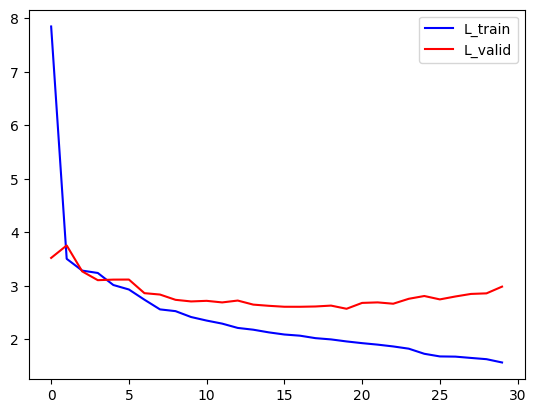

In [ ]:
# Entrainement du modele CNN

torch.manual_seed(42)

epochs = 30
learning_rate = 1e-3
OPTIM = "ADAM"
Model_name = "/content/drive/MyDrive/best_TACO_CNN_detection.pt"

writer = SummaryWriter()

my_CNN = CNN(nbr_classes=nbr_classes).to(device)
my_loss_cls  = nn.CrossEntropyLoss()
my_loss_bbox = nn.MSELoss()

if OPTIM == "ADAM":
    my_optimizer = torch.optim.Adam(my_CNN.parameters(), lr=learning_rate)
    my_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(my_optimizer, patience=3, factor=0.5)
else:
    my_optimizer = torch.optim.SGD(my_CNN.parameters(), lr=learning_rate)
    my_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(my_optimizer, patience=3, factor=0.5)

train_loss = []
valid_loss = []
best_valid_loss = float('inf')
best_iter = 0

for t in tqdm(range(epochs)):
    train_epoch_loss = train_loop(trainloader, my_CNN, my_loss_cls, my_loss_bbox, my_optimizer, device)
    train_loss.append(train_epoch_loss)
    writer.add_scalar('Loss/train', train_epoch_loss, t)

    valid_epoch_loss = valid_loop(validloader, my_CNN, my_loss_cls, my_loss_bbox, device)
    valid_loss.append(valid_epoch_loss)
    writer.add_scalar('Loss/valid', valid_epoch_loss, t)
    my_scheduler.step(valid_epoch_loss)

    if valid_epoch_loss < best_valid_loss:
        best_valid_loss = valid_epoch_loss
        best_iter = t
        print(f"Epoch {t+1}: best validation loss: {best_valid_loss:.4f}")
        torch.save(my_CNN.state_dict(), Model_name)

print('Training done!')
plt.figure()
plt.plot(train_loss, "b", label="L_train")
plt.plot(valid_loss, "r", label="L_valid")
plt.legend()
plt.show()

In [ ]:
# Test du modele

my_best_CNN = CNN(nbr_classes=nbr_classes).to(device)
my_best_CNN.load_state_dict(torch.load(Model_name))

Positifs, Total = perf_loop(testloader, my_best_CNN, device)
print(f"Test accuracy: {Positifs}/{Total} = {(Positifs/Total)*100:.2f}%")
print(f"Best epoch: {best_iter+1}")
print(f"Trainable parameters: {count_parameters(my_best_CNN)}")

writer.add_hparams({'lr': learning_rate, 'bsize': batch_size},
                   {'hparam/accuracy': Positifs/Total, 'hparam/loss': best_valid_loss})
writer.close()

NameError: name 'CNN' is not defined

In [ ]:
# Test du modele


label = "supercategory"
sc = sorted(df[label].unique())
nbr_classes = len(sc)
Model_name = "/content/drive/MyDrive/best_TACO_CNN_detection.pt"

my_best_CNN = CNN(nbr_classes=nbr_classes).to(device)
my_best_CNN.load_state_dict(torch.load(Model_name, map_location=device, weights_only=True))
my_best_CNN.eval()

Positifs, Total = perf_loop(testloader, my_best_CNN, device)
print(f"Test accuracy: {Positifs}/{Total} = {(Positifs/Total)*100:.2f}%")
print(f"Trainable parameters: {count_parameters(my_best_CNN)}")

Test accuracy: 230/719 = 31.99%
Trainable parameters: 548128
